# HR-аналитика для компании «Работа с заботой».

# Описание проекта

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли.

**Задачи проекта**

Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.
Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**Задача 1: предсказание уровня удовлетворённости сотрудника**

Для этой задачи заказчик предоставил данные с признаками:

- `id` — уникальный идентификатор сотрудника
- `dept` — отдел, в котором работает сотрудник
- `level` — уровень занимаемой должности
- `workload` — уровень загруженности сотрудника
- `employment_years` — длительность работы в компании (в годах)
- `last_year_promo` — показывает, было ли повышение за последний год
- `last_year_violations` — показывает, нарушал ли сотрудник трудовой договор за последний год
- `supervisor_evaluation` — оценка качества работы сотрудника, которую дал руководитель
- `salary` — ежемесячная зарплата сотрудника
- `job_satisfaction_rate` — уровень удовлетворённости сотрудника работой в компании, целевой признак


Тренировочная выборка: 

<u>train_job_satisfaction_rate.csv</u>

Входные признаки тестовой выборки: 

<u>test_features.csv</u>

Целевой признак тестовой выборки:

<u>test_target_job_satisfaction_rate.csv</u>

**Задача 2: предсказание увольнения сотрудника из компании**

Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это `quit` — увольнение сотрудника из компании.

Тренировочная выборка:

<u>train_quit.csv</u>

Входные признаки тестовой выборки те же, что и в прошлой задаче:

<u>test_features.csv</u>

Целевой признак тестовой выборки:

<u>test_target_quit.csv</u>

# Задача 1: предсказание уровня удовлетворённости сотрудника

## Шаг 1. Загрузка данных

In [1]:
!pip install shap -q
!pip install phik -q
!pip install --upgrade scikit-learn


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import math
import numpy as np
import time
import phik
import shap
import warnings
warnings.filterwarnings('ignore')
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  (
    f1_score, 
    roc_auc_score, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    make_scorer,
    classification_report)
from phik import phik_matrix, report
from phik.report import plot_correlation_matrix
from sklearn.dummy import DummyClassifier

In [3]:
try:
    job_satisfaction = pd.read_csv('/datasets/train_job_satisfaction_rate.csv', decimal='.', sep=',')
    test_features = pd.read_csv('/datasets/test_features.csv', decimal='.', sep=',')
    test_target = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv', decimal='.', sep=',') 
except:
    job_satisfaction = pd.read_csv("C:/Users/user/Downloads/train_job_satisfaction_rate.csv", decimal='.', sep=',')
    test_features = pd.read_csv("C:/Users/user/Downloads/test_features.csv", decimal='.', sep=',')
    test_target = pd.read_csv("C:/Users/user/Downloads/test_target_job_satisfaction_rate.csv", decimal='.', sep=',')

In [4]:
def descr (df):
    display(df.head(5))
    display(df.info()) 
    print(f'Количество дубликатов: {df.duplicated().sum()}')
    print(f'Количество пропусков: {df.isna().sum()}')

In [5]:
descr (job_satisfaction)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


None

Количество дубликатов: 0
Количество пропусков: id                       0
dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64


In [6]:
descr (test_features)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

Количество дубликатов: 0
Количество пропусков: id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64


In [7]:
descr (test_target)

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


None

Количество дубликатов: 0
Количество пропусков: id                       0
job_satisfaction_rate    0
dtype: int64


> Загруженные данные можно просматривать без проблем. Названия столбцов соответствуют правилам оформления. Отмечу, что в наборах данных отсутствуют явные дубликаты. Однако в обеих таблицах присутствуют пропущенные значения, которые мы обработаем позже.

## Шаг 2. Предобработка данных

In [8]:
# просмотрим категориальные признаки на наличие скрытых дубликатов и неточностей
def cat_info (df):
    display (df.head())
    print(df.columns)

In [9]:
cat_info (job_satisfaction)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary', 'job_satisfaction_rate'],
      dtype='object')


In [10]:
job_satisfaction['dept'].unique()

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

In [11]:
test_features['dept'] = test_features['dept'].replace(' ', np.nan)

In [12]:
job_satisfaction['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [13]:
job_satisfaction['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

In [14]:
test_features['workload'] = test_features['workload'].replace(' ', np.nan)

In [15]:
job_satisfaction['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [16]:
job_satisfaction['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [17]:
cat_info (test_features)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary'],
      dtype='object')


In [18]:
test_features['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
      dtype=object)

In [19]:
test_features['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [20]:
test_features['workload'].unique()

array(['medium', 'low', 'high', nan], dtype=object)

In [21]:
test_features['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [22]:
test_features['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

> При просмотре категориальных данных не было выявлено неявных дублей или ошибок. В двух столбцах пустые значения были заменены на `nan`.

## Шаг 3. Исследовательский анализ данных

In [23]:
job_satisfaction.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [24]:
# создадим список с числовыми переменными
num_col=['salary', 'job_satisfaction_rate']
# создадим список с названиями графиков
titles_num = ['Ежемесячная зарплата сотрудника', 'Уровень удовлетворённости сотрудника работой']

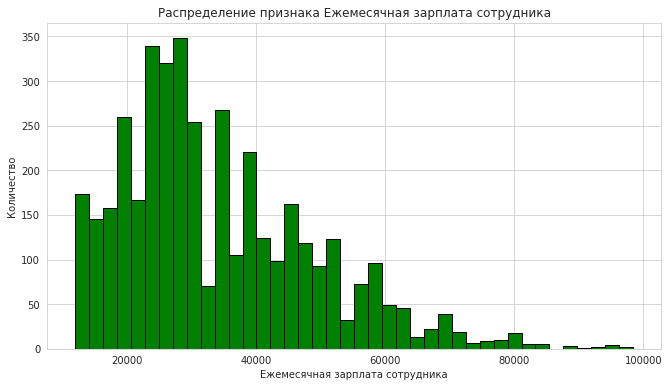

count     4000.000000
mean     33926.700000
std      14900.703838
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      98400.000000
Name: salary, dtype: float64


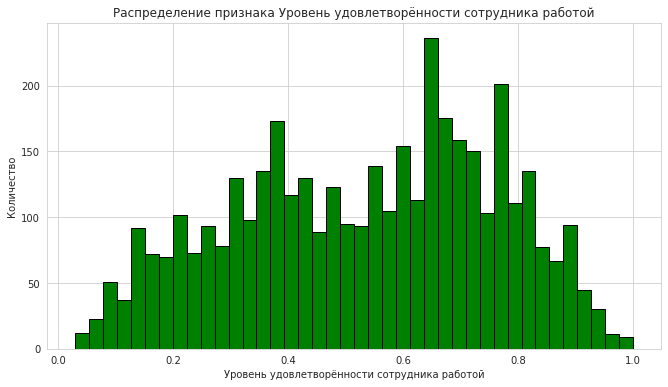

count    4000.000000
mean        0.533995
std         0.225327
min         0.030000
25%         0.360000
50%         0.560000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64


In [25]:
# построим гистограммы и рассмотрим mean,  median, min, max
for i in range(len(num_col)):
    sns.set_style('whitegrid')
    plt.figure(figsize=(11, 6))
    plt.hist(job_satisfaction[num_col[i]], color = 'g', edgecolor = 'black', bins = 40)
    plt.title(f"Распределение признака {titles_num[i]}")
    plt.ylabel("Количество")
    plt.xlabel(titles_num[i])
    plt.show()
    print(job_satisfaction[num_col[i]].describe())

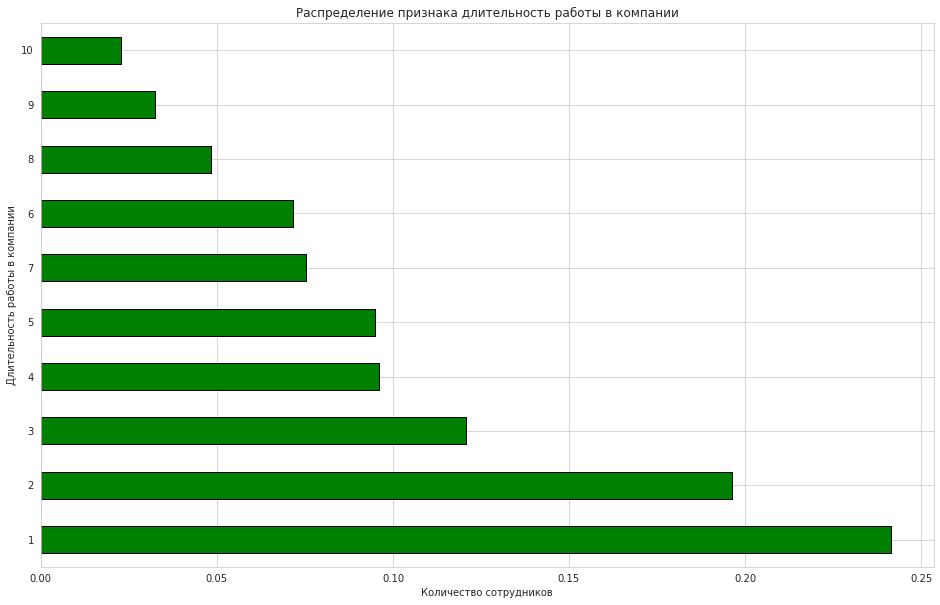

count    4000.000000
mean        3.718500
std         2.542513
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


In [26]:
job_satisfaction['employment_years'].value_counts(normalize=True).plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака длительность работы в компании')
plt.xlabel('Количество сотрудников')
plt.ylabel('Длительность работы в компании')
plt.show()
print(job_satisfaction['employment_years'].describe())

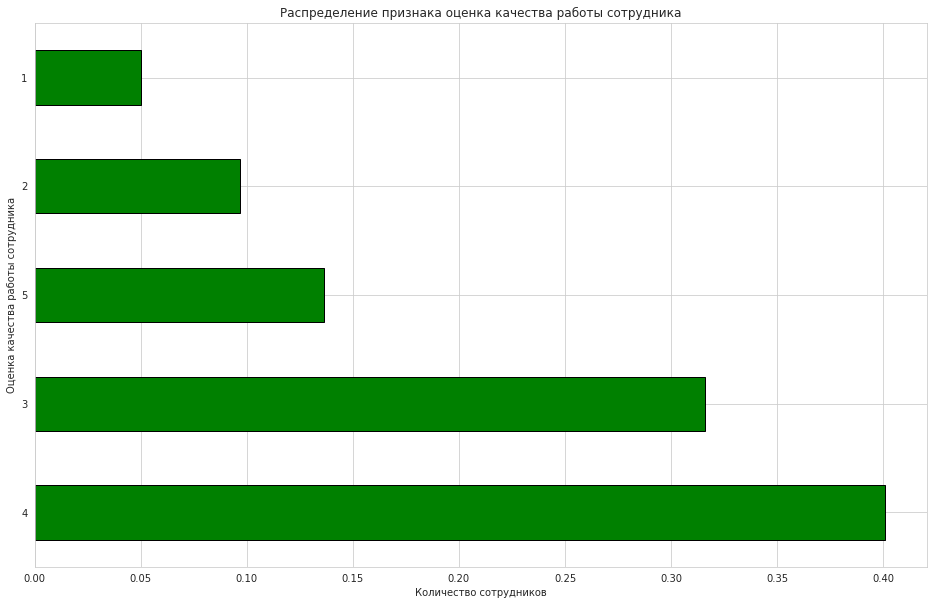

count    4000.000000
mean        3.476500
std         1.008812
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [27]:
job_satisfaction['supervisor_evaluation'].value_counts(normalize=True).plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака оценка качества работы сотрудника')
plt.xlabel('Количество сотрудников')
plt.ylabel('Оценка качества работы сотрудника')
plt.show()
print(job_satisfaction['supervisor_evaluation'].describe())

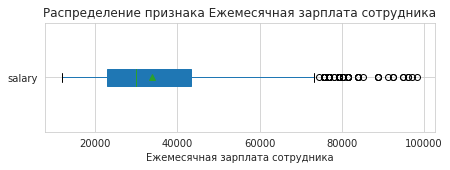

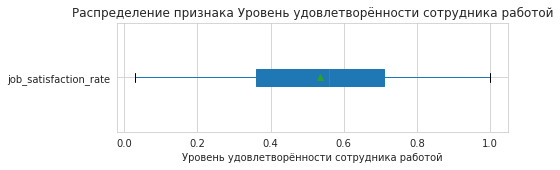

In [28]:
for i in range(len(num_col)):
    plt.figure(figsize=(7, 2))
    job_satisfaction.boxplot(num_col[i], patch_artist=True, vert=False, showmeans=True )
    plt.title(f"Распределение признака {titles_num[i]}")
    plt.xlabel(titles_num[i])
    plt.show()

> Анализ показал, что большинство сотрудников работают в компании от одного до шести лет, а средний стаж работы составляет три года. Оценка качества сотрудников находится на хорошем уровне: большинство сотрудников получают оценки 3 и 4, однако есть сотрудник с оценкой 1, который может быть кандидатом на увольнение.

> Средняя зарплата не сильно превышает медиану и составляет 33 926,70 тысячи рублей. Максимальная зарплата достигает 98 400 рублей, а минимальная — 12 000 рублей. Удовлетворённость сотрудников работой соответствует оценке качества и находится на хорошем уровне. В целом условия и работа в компании неплохие, но могут быть улучшены.

In [29]:
# создадим список с категориальных перемен
cat_col=['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
# создадим список с названиями графиков 
titles_cat_col= ['Отдел, в котором работает сотрудник', 'Уровень занимаемой должности', 'Уровень загруженности сотрудника',
                 'Было ли повышение за последний год', 'Нарушал ли сотрудник трудовой договор за последний год']

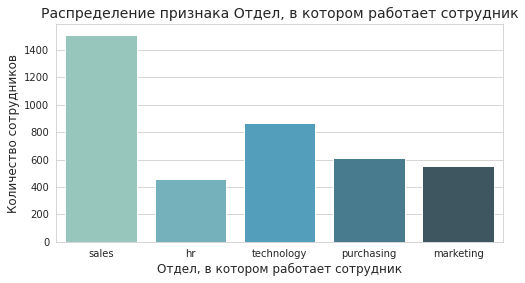

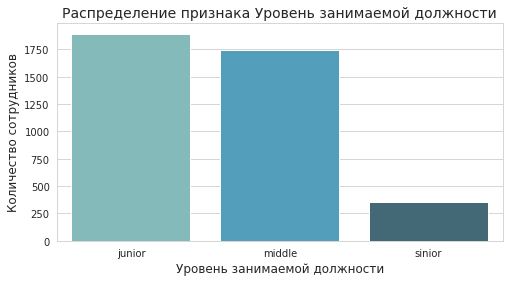

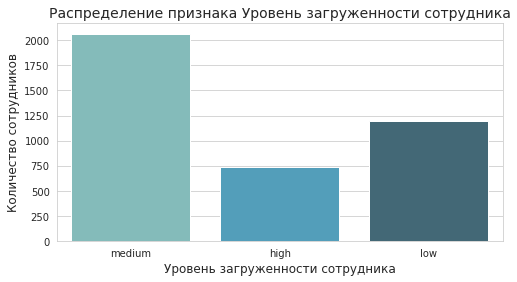

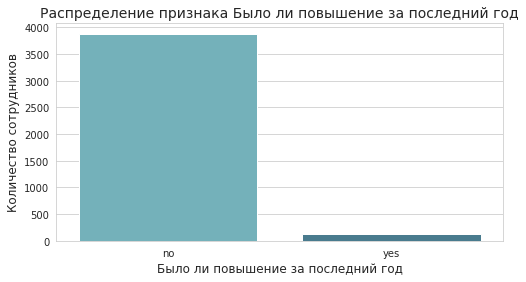

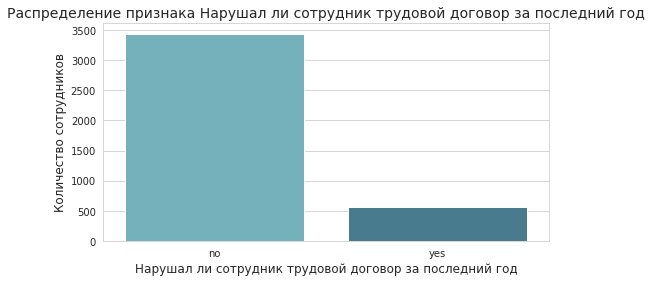

In [30]:
for i in range(len(cat_col)):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=job_satisfaction, x=cat_col[i], palette='GnBu_d')
    plt.title(f"Распределение признака {titles_cat_col[i]}", size=14)
    plt.ylabel('Количество сотрудников', size=12)
    plt.xlabel(titles_cat_col[i], size=12)
    plt.show()


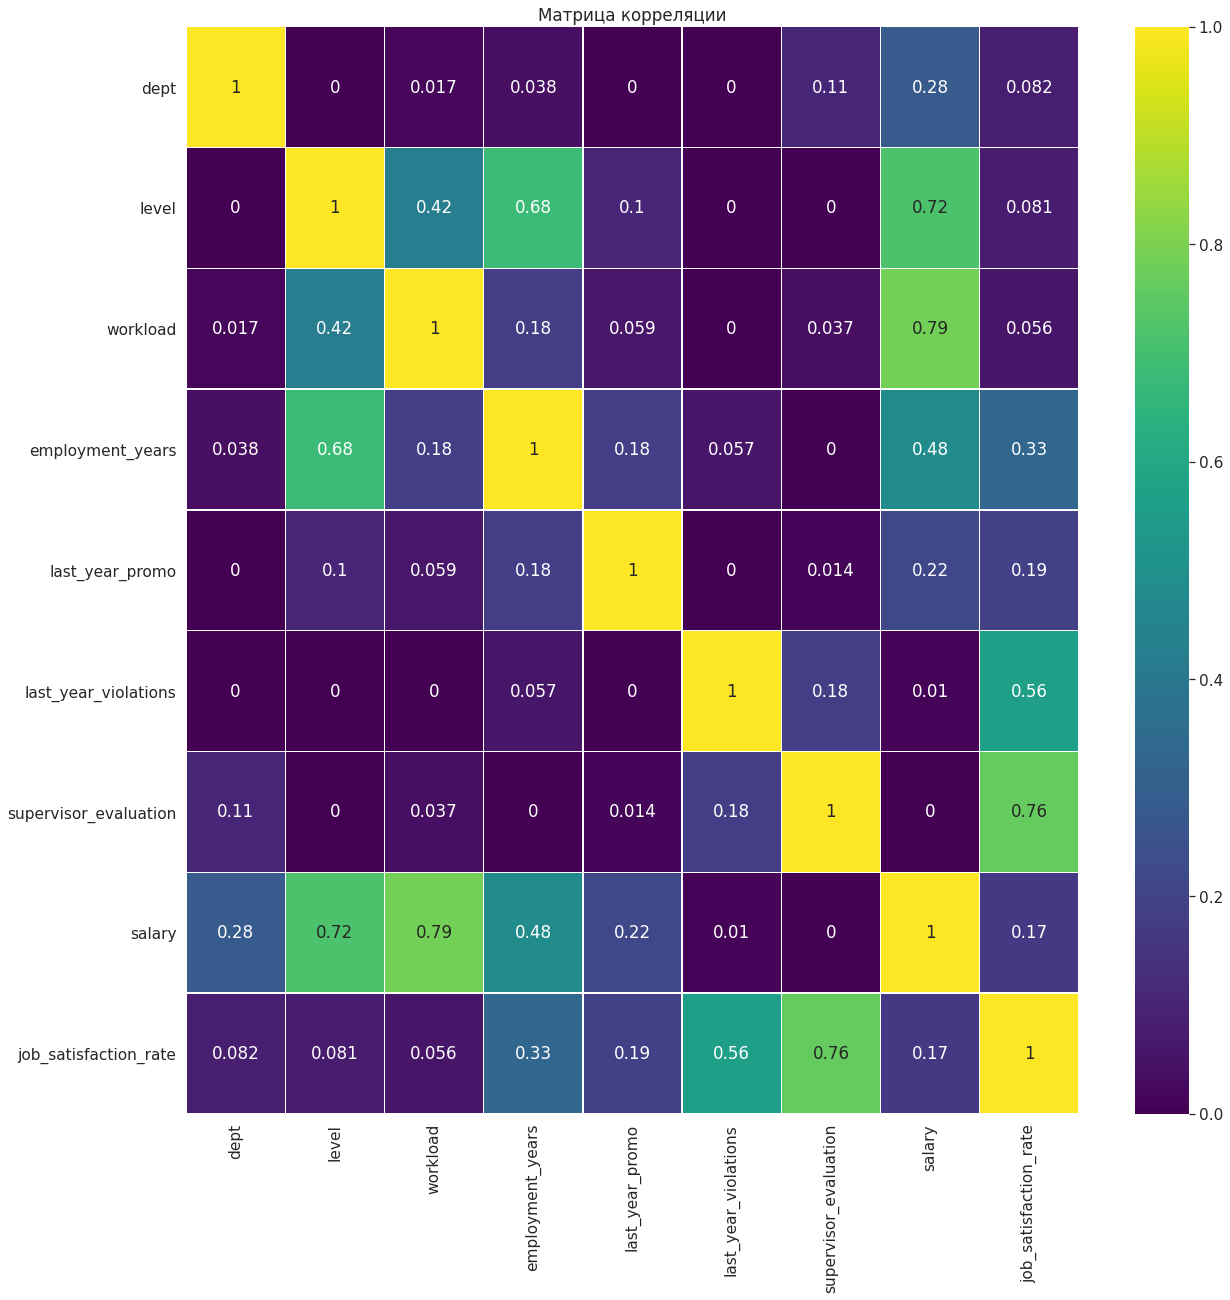

In [31]:
job_satisfaction_1=job_satisfaction.drop(['id'], axis=1)
corr_matrix = job_satisfaction_1.phik_matrix(interval_cols = num_col)
sns.set(font_scale=1.4)
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='viridis')
plt.title('Матрица корреляции')
plt.show()

> Корреляционный анализ показал высокую степень корреляции между целевым показателем — удовлетворённостью сотрудника работой в компании и отделе, занимаемой должностью, а также оценкой качества работы сотрудника. Однако сильная корреляционная зависимость между этими признаками отсутствует. Мультиколлинеарность в данном случае отсутствует, поэтому удалять переменные не нужно.

In [32]:
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [33]:
# создадим список с числовыми переменными
num_col_1=['salary']
# создадим список с названиями графиков
titles_num_1 = ['Ежемесячная зарплата сотрудника']

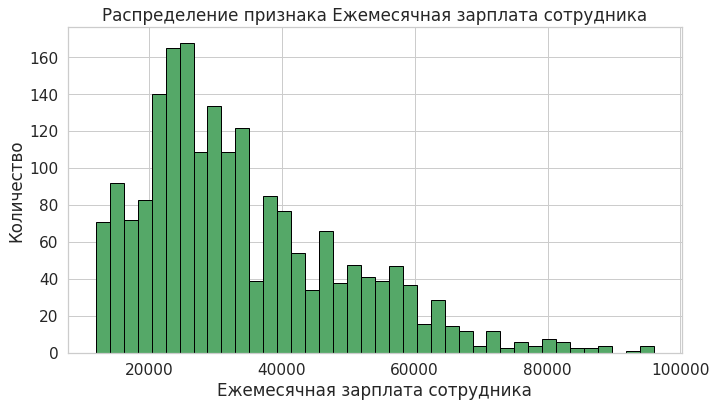

count     2000.000000
mean     34066.800000
std      15398.436729
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64


In [34]:
# построим гистограммы и рассмотрим mean,  median, min, max
for i in range(len(num_col_1)):
    sns.set_style('whitegrid')
    plt.figure(figsize=(11, 6))
    plt.hist(test_features[num_col_1[i]], color = 'g', edgecolor = 'black', bins = 40)
    plt.title(f"Распределение признака {titles_num_1[i]}")
    plt.ylabel("Количество")
    plt.xlabel(titles_num_1[i])
    plt.show()
    print(test_features[num_col_1[i]].describe())

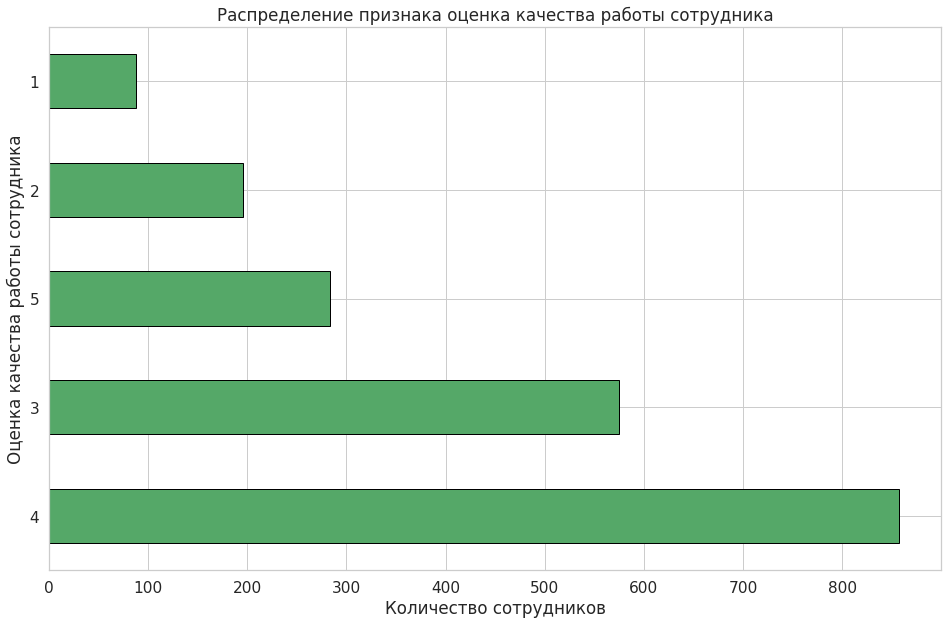

count    2000.000000
mean        3.526500
std         0.996892
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [35]:
test_features['supervisor_evaluation'].value_counts().plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака оценка качества работы сотрудника')
plt.xlabel('Количество сотрудников')
plt.ylabel('Оценка качества работы сотрудника')
plt.show()
print(test_features['supervisor_evaluation'].describe())

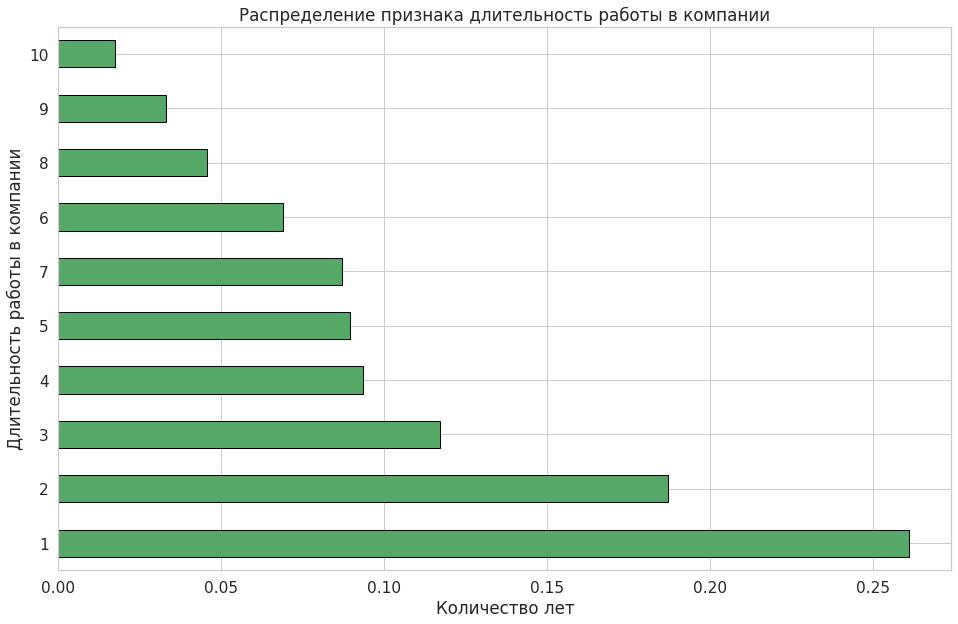

count    2000.000000
mean        3.666500
std         2.537222
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


In [36]:
test_features['employment_years'].value_counts(normalize=True).plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака длительность работы в компании')
plt.xlabel('Количество лет')
plt.ylabel('Длительность работы в компании')
plt.show()
print(test_features['employment_years'].describe())

In [37]:
# создадим список с категориальных перемен
cat_col_1=['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
# создадим список с названиями графиков 
titles_cat_col_1= ['Отдел, в котором работает сотрудник', 'Уровень занимаемой должности', 'Уровень загруженности сотрудника', 
                   'Было ли повышение за последний год', 'Нарушал ли сотрудник трудовой договор за последний год']

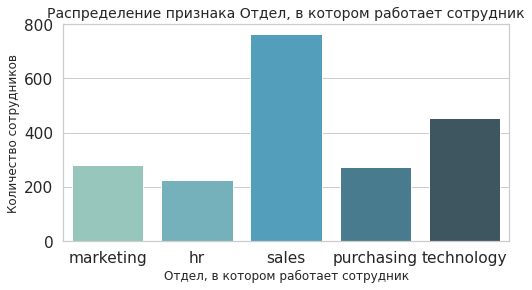

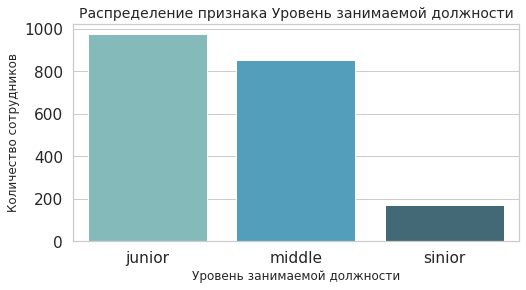

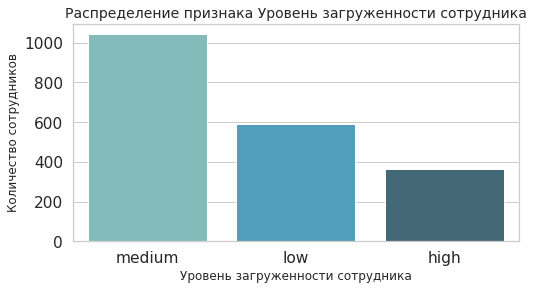

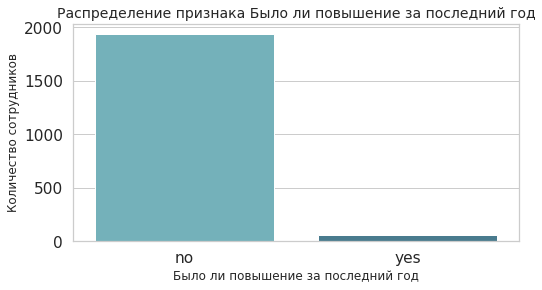

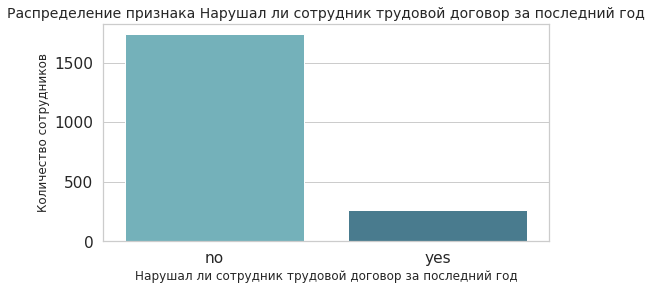

In [38]:
for i in range(len(cat_col)):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=test_features, x=cat_col_1[i], palette='GnBu_d')
    plt.title(f"Распределение признака {titles_cat_col_1[i]}", size=14)
    plt.ylabel('Количество сотрудников', size=12)
    plt.xlabel(titles_cat_col_1[i], size=12)
    plt.show()


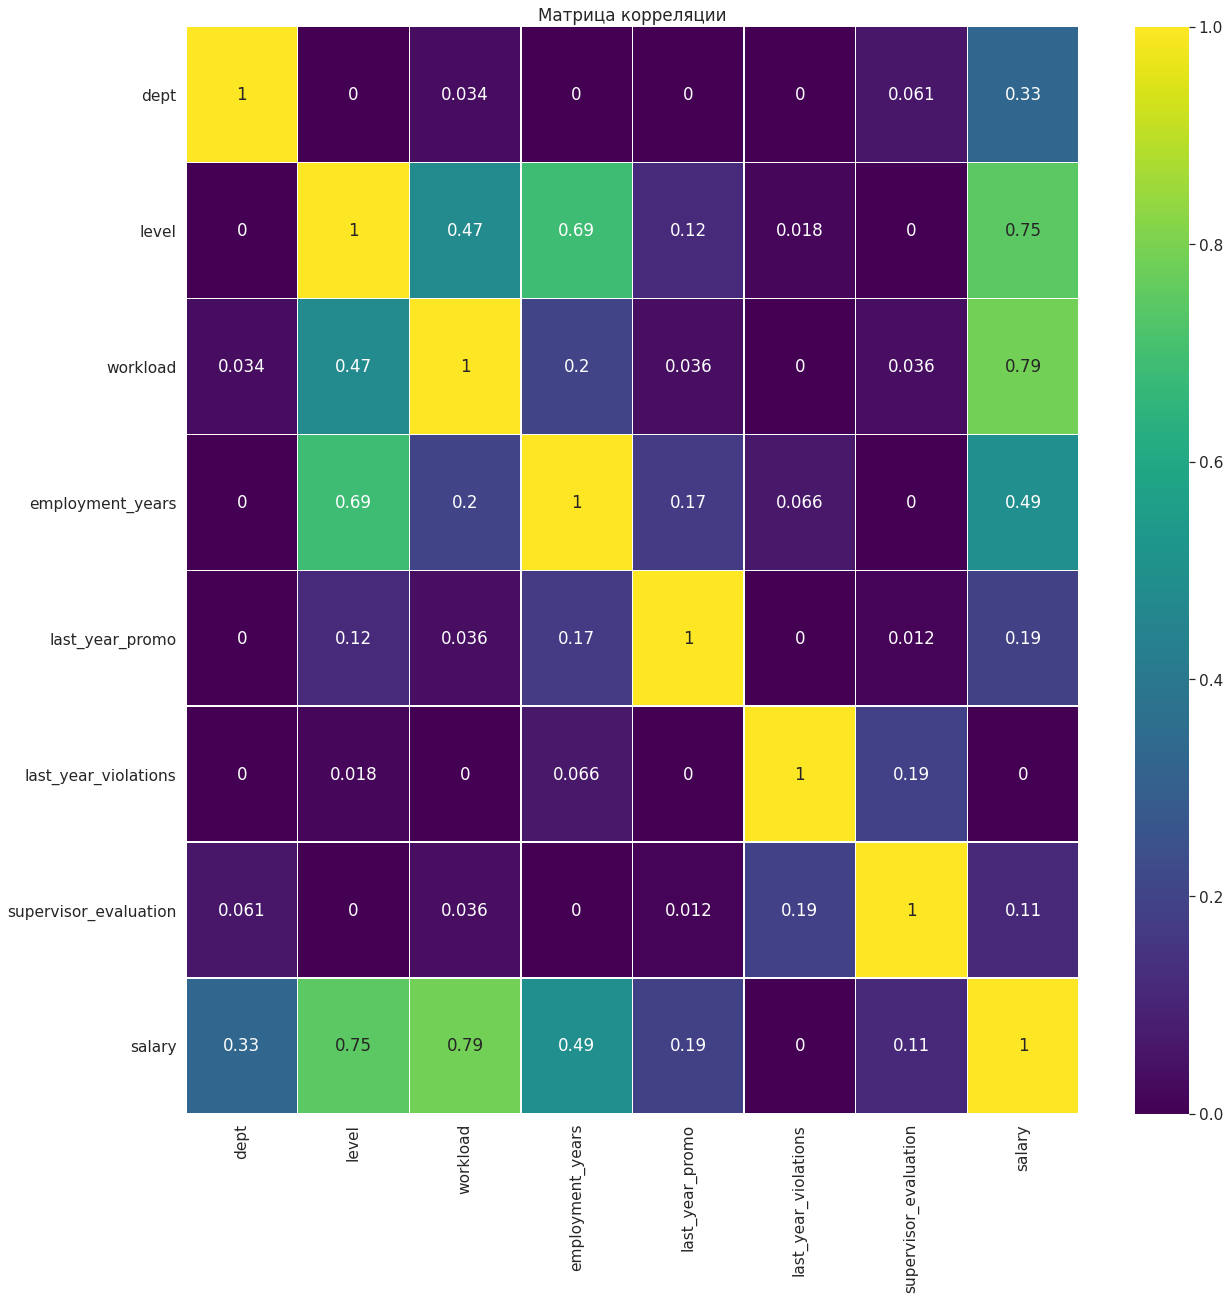

In [39]:
test_features_1=test_features.drop(['id'], axis=1)
corr_matrix = test_features_1.phik_matrix (interval_cols = num_col)
sns.set(font_scale=1.4)
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='viridis')
plt.title('Матрица корреляции')
plt.show()

> Анализ выборки без учёта целевого признака не выявил существенных изменений.

## Шаг 4. Подготовка данных

Подготовку признаков выполним в пайплайне, дополнив пайплайн шага предобработки. При кодировании важно учесть особенности признаков и моделей и использовании как минимум два кодировщика.

Для переменных `dept`, `last_year_promo` и `last_year_violations` используем кодировку <u>OneHotEncoder</u>. 

Для переменных `level` и `workload` применим кодировку <u>OrdinalEncoder</u>. 

Переменные `employment_years`, `supervisor_evaluation` и `salary` нуждаются в масштабировании.

## Шаг 5. Обучение моделей

In [40]:
train_1 = job_satisfaction.drop(['id'], axis=1)
train_1.drop_duplicates(inplace=True)

In [41]:
RANDOM_STATE = 100
TEST_SIZE = 0.25
X_train = train_1.drop('job_satisfaction_rate', axis=1)
y_train = train_1['job_satisfaction_rate'] 


# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations'] 
ord_columns = ['level', 'workload']
num_columns = ['employment_years', 'supervisor_evaluation', 'salary']


ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'], 
                    ['low', 'medium', 'high'] 
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),

    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])
 
param_grid = [

    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 21),
        'models__min_samples_split': range(2, 21),
        'models__max_features': range(2, 21),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
    
]


def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))



smape_scorer = make_scorer(score_func=smape, greater_is_better=False)
 
# выберем лучшую модель и параметры с помощью RandomizedSearchCV()
r_search = RandomizedSearchCV(
    pipe_final, 
    param_grid,
    n_iter=10,
    cv=5,
    scoring=smape_scorer,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# обучаем лучшую модель на тренировочных данных
r_search.fit(X_train, y_train)

# выводим на экран лучшую модель
print('Лучшая модель и её параметры:\n\n', r_search.best_estimator_)
print(f'Параметры лучшей модели:\n{r_search.best_params_}')
print ('Метрика лучшей модели на тренировочной выборке:', round(r_search.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

In [42]:
test_features = test_features.merge(test_target, on='id', how='left')
X_test = test_features.drop(['id', 'job_satisfaction_rate'], axis=1)
y_test = test_features['job_satisfaction_rate']
best_model = r_search.best_estimator_
print(f'Метрика SMAPE лучшей модели по кросс-валидации на обучающих данных: {round(r_search.best_score_*(-1),4)}')

Метрика SMAPE лучшей модели по кросс-валидации на обучающих данных: 15.1814


In [43]:
print(f'Метрика sMAPE лучшей модели на тестовой выборке: {round(smape(y_test, best_model.predict(X_test)),4)}')

Метрика sMAPE лучшей модели на тестовой выборке: 13.6159


## Шаг 6. Оформление выводов

В ходе обучения модели был построен пайплайн с использованием методов DecisionTreeClassifier() и LinearRegression(). Оптимальные параметры модели включают следующие значения:

- preprocessor__num: StandardScaler();

- models__min_samples_split: 12;

- models__max_features: 10;models__max_depth: 17;

- models: DecisionTreeRegressor(random_state=100).

На обучающей выборке метрика модели составляет -15.18. SMAPE для лучшей модели на обучающих данных равна 15.1814, а sMAPE для тестовой выборки — 13.6159.

# Задача 2: предсказание увольнения сотрудника из компании

## Шаг 1. Загрузка данных

In [44]:
try:
    train_quit = pd.read_csv('/datasets/train_quit.csv')
    test_features = pd.read_csv('/datasets/test_features.csv')
    test_target_quit = pd.read_csv('/datasets/test_target_quit.csv')
except:
    train_quit = pd.read_csv("C:/Users/user/Downloads/train_quit.csv", decimal='.', sep=',')
    test_features = pd.read_csv("C:/Users/user/Downloads/test_features.csv", decimal='.', sep=',')
    test_target_quit = pd.read_csv("C:/Users/user/Downloads/test_target_quit.csv", decimal='.', sep=',')

In [45]:
descr (train_quit)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


None

Количество дубликатов: 0
Количество пропусков: id                       0
dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64


In [46]:
descr (test_features)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


None

Количество дубликатов: 0
Количество пропусков: id                       0
dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64


In [47]:
descr (test_target_quit)

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


None

Количество дубликатов: 0
Количество пропусков: id      0
quit    0
dtype: int64


> Загруженные данные не содержат ошибок. Названия столбцов соответствуют правилам. Отсутствуют дубликаты. В двух таблицах есть пропущенные значения, которые будут обработаны позже.

## Шаг 2. Предобработка данных

In [48]:
for col in train_quit.iloc[:, 1:8]:
    print(train_quit[col].unique ())

['sales' 'purchasing' 'marketing' 'technology' 'hr']
['middle' 'junior' 'sinior']
['high' 'medium' 'low']
[ 2  5  1  8  4  7  3  9  6 10]
['no' 'yes']
['no' 'yes']
[4 1 3 5 2]


In [49]:
for col in test_features.iloc[:, 1:8]:
    print(test_features[col].unique ())

['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
['junior' 'middle' 'sinior' nan]
['medium' 'low' 'high' ' ']
[ 2  1  5  6  3  9  7  4  8 10]
['no' 'yes']
['no' 'yes']
[5 4 3 1 2]


In [50]:
test_features['dept'] = test_features['dept'].replace(' ', np.nan)
test_features['workload'] = test_features['workload'].replace(' ', np.nan)

> Проверили категориальные данные на наличие скрытых дублей и ошибок при заполнении. Ничего подозрительного не обнаружили. В двух столбцах заменили пустые значения на nan.

## Шаг 3. Исследовательский анализ данных

In [51]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [52]:
# создадим список с числовыми переменными
num_col_2=['salary']
# создадим список с названиями графиков
titles_num_2 = ['Ежемесячная зарплата сотрудника']

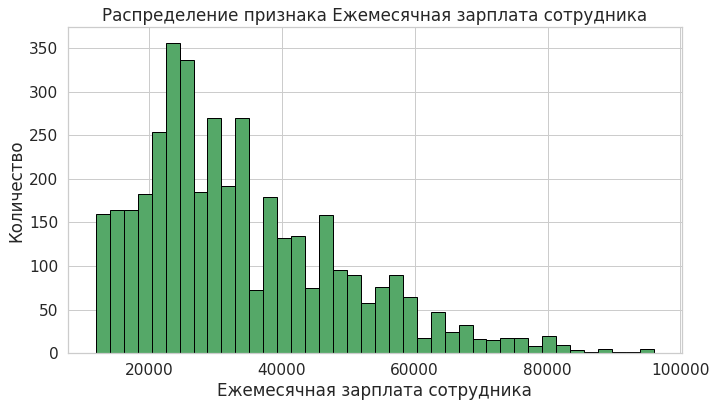

count     4000.000000
mean     33805.800000
std      15152.415163
min      12000.000000
25%      22800.000000
50%      30000.000000
75%      43200.000000
max      96000.000000
Name: salary, dtype: float64


In [53]:
# построим гистограммы и рассмотрим mean,  median, min, max
for i in range(len(num_col_2)):
    sns.set_style('whitegrid')
    plt.figure(figsize=(11, 6))
    plt.hist(train_quit[num_col_2[i]], color = 'g', edgecolor = 'black', bins = 40)
    plt.title(f"Распределение признака {titles_num[i]}")
    plt.ylabel("Количество")
    plt.xlabel(titles_num[i])
    plt.show()
    print(train_quit[num_col_2[i]].describe())

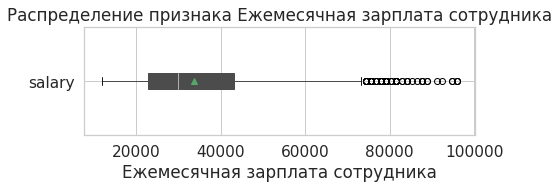

In [54]:
for i in range(len(num_col_2)):
    plt.figure(figsize=(7, 2))
    train_quit.boxplot(num_col_2[i], patch_artist=True, vert=False, showmeans=True )
    plt.title(f"Распределение признака {titles_num_2[i]}")
    plt.xlabel(titles_num_2[i])
    plt.show();

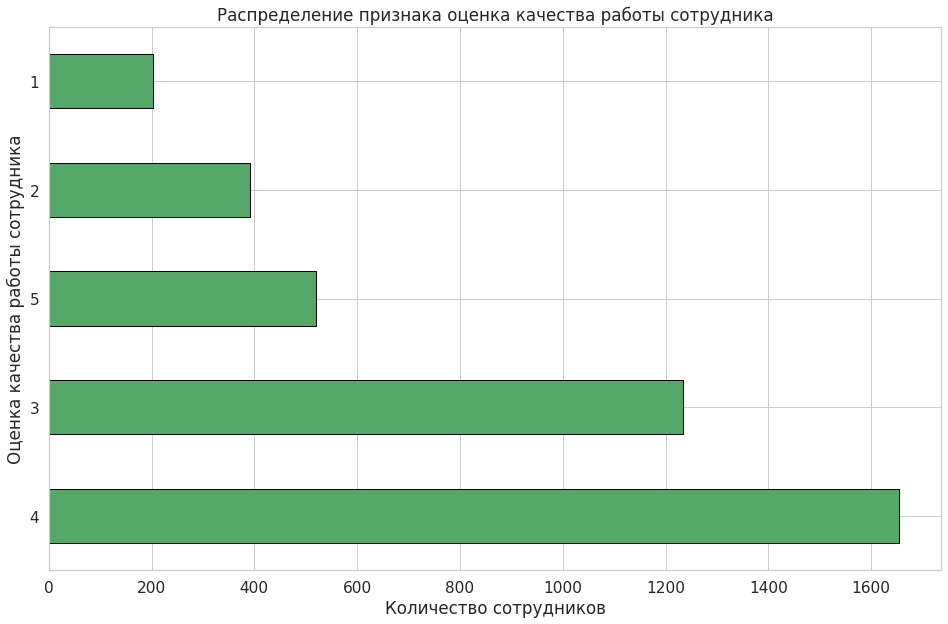

count    4000.000000
mean        3.474750
std         1.004049
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [55]:
train_quit['supervisor_evaluation'].value_counts().plot(kind='barh', figsize=(16,10), color = 'g',  ec ='black', grid=True)
plt.title(f'Распределение признака оценка качества работы сотрудника')
plt.xlabel('Количество сотрудников')
plt.ylabel('Оценка качества работы сотрудника')
plt.show()
print(train_quit['supervisor_evaluation'].describe())

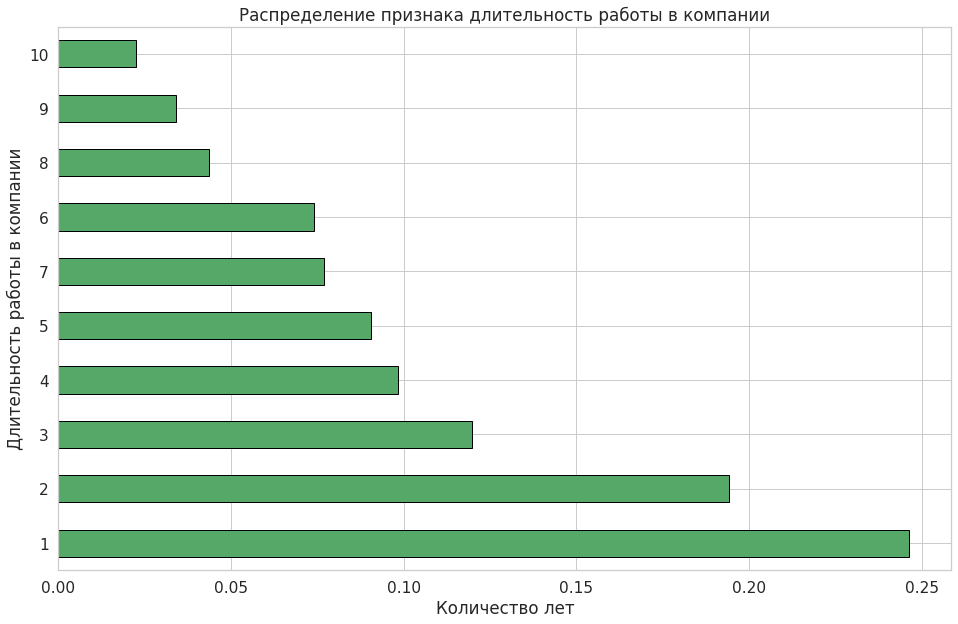

count    4000.000000
mean        3.701500
std         2.541852
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


In [56]:
train_quit['employment_years'].value_counts(normalize=True).plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака длительность работы в компании')
plt.xlabel('Количество лет')
plt.ylabel('Длительность работы в компании')
plt.show()
print(train_quit['employment_years'].describe())

In [57]:
# создадим список с категориальных перемен
cat_col_2=['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations', 'quit']
# создадим список с названиями графиков 
titles_cat_col_2= ['Отдел, в котором работает сотрудник', 'Уровень занимаемой должности', 'Уровень загруженности сотрудника', 
                   'Было ли повышение за последний год', 'Нарушал ли сотрудник трудовой договор за последний год', 
                   ' Увольнение сотрудника из компании']

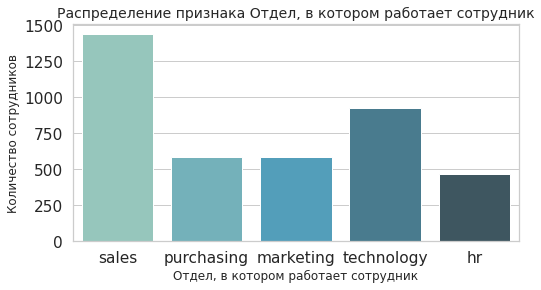

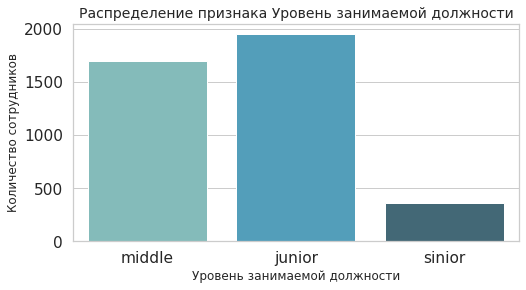

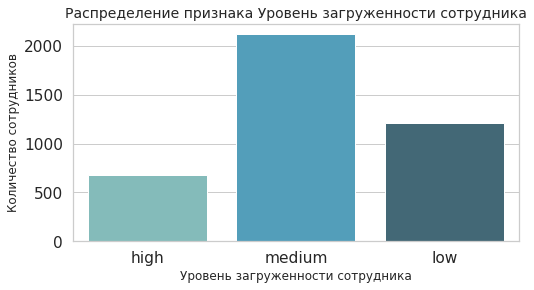

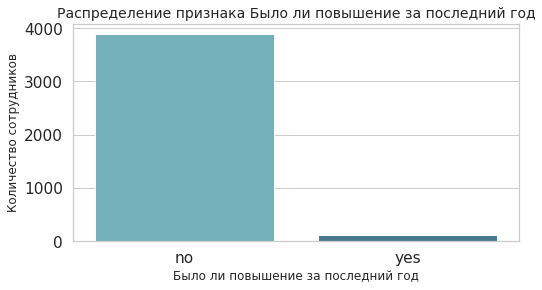

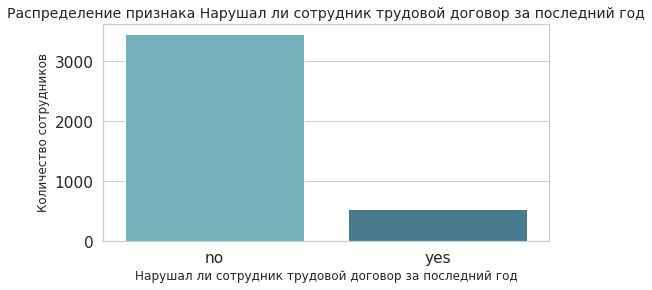

In [58]:
for i in range(len(cat_col)):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=train_quit, x=cat_col_2[i], palette='GnBu_d')
    plt.title(f"Распределение признака {titles_cat_col_2[i]}", size=14)
    plt.ylabel('Количество сотрудников', size=12)
    plt.xlabel(titles_cat_col_2[i], size=12)
    plt.show()


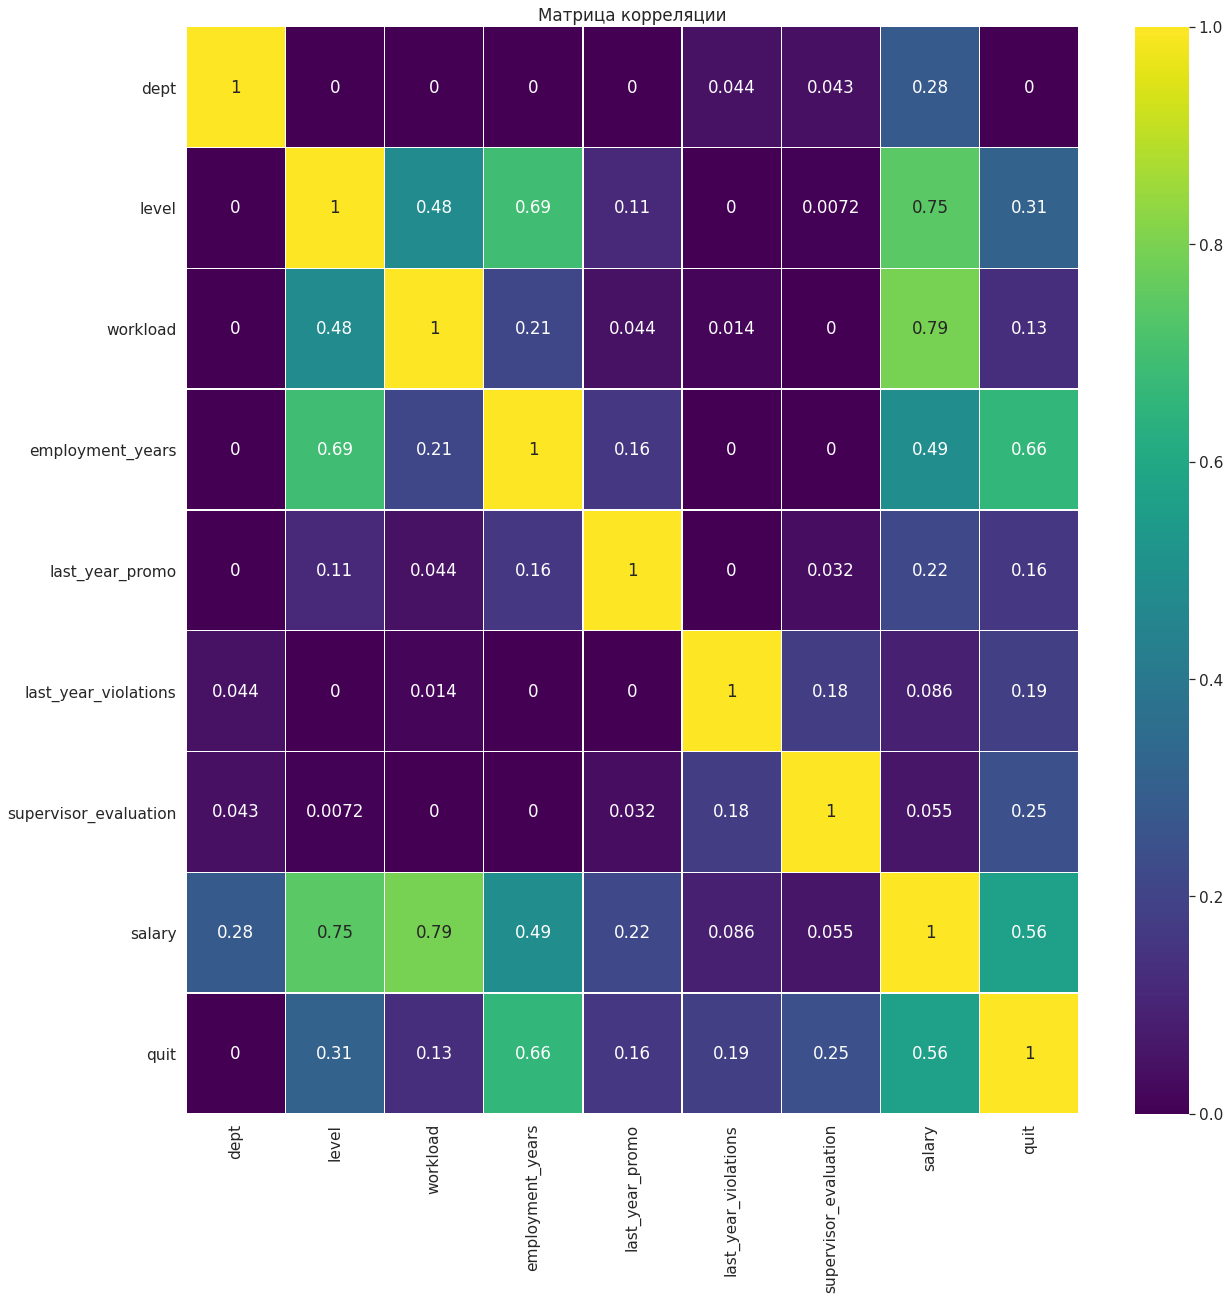

In [59]:
train_quit_1=train_quit.drop(['id'], axis=1)
corr_matrix = train_quit_1.phik_matrix(interval_cols = num_col)
sns.set(font_scale=1.4)
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='viridis')
plt.title('Матрица корреляции')
plt.show()

> В результате анализа данных из `train_quit` не было обнаружено значительных различий между ними и данными из анализа <u>job_satisfaction</u>. Однако следует учесть, что показатель `quit` имеет высокие значения и связан с уровнем заработной платы и продолжительностью работы. Мы разделим `train_quit` на две вспомогательные таблицы: в первой таблице будут представлены ушедшие сотрудники, а во второй — оставшиеся.

In [60]:
df = train_quit[train_quit['quit'] == 'yes']

In [61]:
df.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
5,699916,sales,junior,low,1,no,yes,3,18000,yes
9,613206,technology,middle,medium,2,no,no,3,45600,yes
24,468145,technology,junior,medium,2,no,no,3,30000,yes
25,982346,marketing,junior,medium,3,no,no,3,30000,yes


In [62]:
# создадим список перемен
num=['salary']
# создадим список с названиями графиков 
titles_num= ['Длительность работы в компании', 'Оценка качества работы сотрудника', 'Ежемесячная зарплата сотрудника']

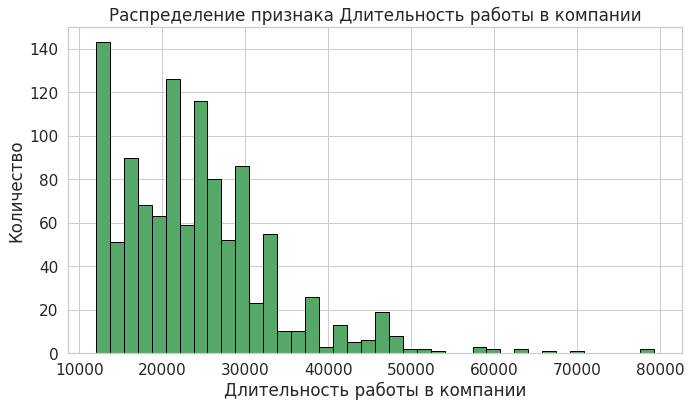

count     1128.000000
mean     23885.106383
std       9351.599505
min      12000.000000
25%      16800.000000
50%      22800.000000
75%      27600.000000
max      79200.000000
Name: salary, dtype: float64


In [63]:
#Построим гистограммы и рассмотрим mean,  median, min, max
for i in range(len(num)):
    sns.set_style('whitegrid')
    plt.figure(figsize=(11, 6))
    plt.hist(df[num[i]], color = 'g', edgecolor = 'black', bins = 40)
    plt.title(f"Распределение признака {titles_num[i]}")
    plt.ylabel("Количество")
    plt.xlabel(titles_num[i])
    plt.show()
    print(df[num[i]].describe())

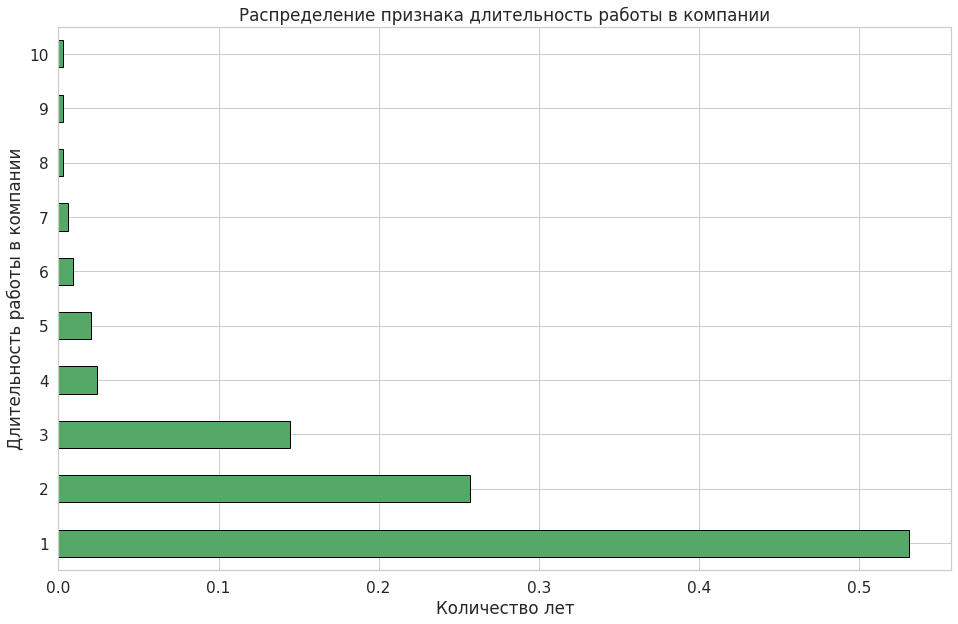

count    1128.000000
mean        1.844858
std         1.274920
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: employment_years, dtype: float64


In [64]:
df['employment_years'].value_counts(normalize=True).plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака длительность работы в компании')
plt.xlabel('Количество лет')
plt.ylabel('Длительность работы в компании')
plt.show()
print(df['employment_years'].describe())

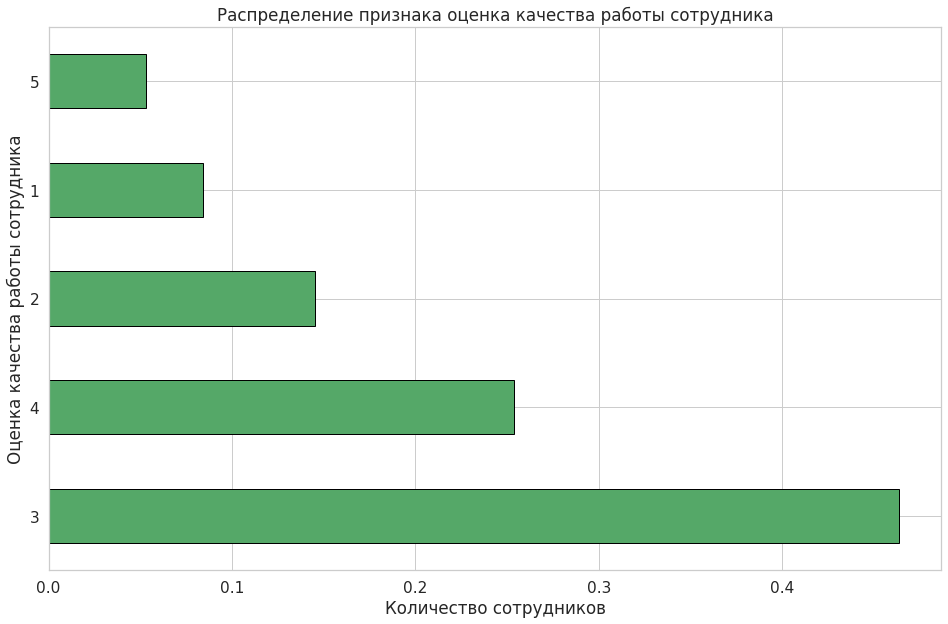

count    1128.000000
mean        3.046099
std         0.973291
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64


In [65]:
df['supervisor_evaluation'].value_counts(normalize=True).plot(kind='barh', figsize=(16,10), color = 'g', ec ='black', grid=True)
plt.title(f'Распределение признака оценка качества работы сотрудника')
plt.xlabel('Количество сотрудников')
plt.ylabel('Оценка качества работы сотрудника')
plt.show()
print(df['supervisor_evaluation'].describe())

In [66]:
# создадим список с категориальных перемен
cat=['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
# создадим список с названиями графиков 
titles_cat= ['Отдел, в котором работает сотрудник', 'Уровень занимаемой должности', 'Уровень загруженности сотрудника', 
             'Было ли повышение за последний год', 'Нарушал ли сотрудник трудовой договор за последний год']

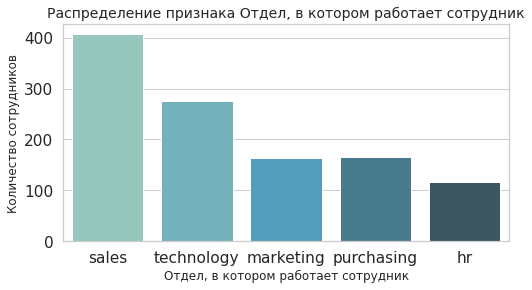

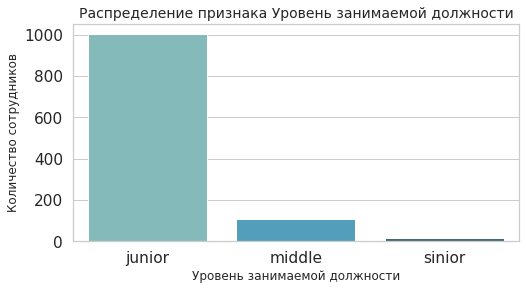

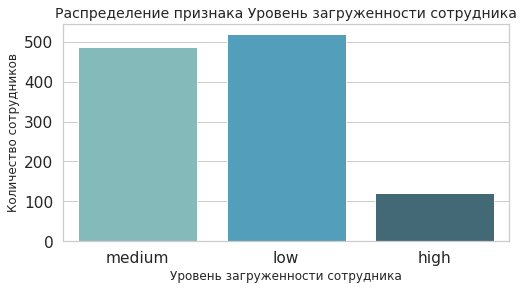

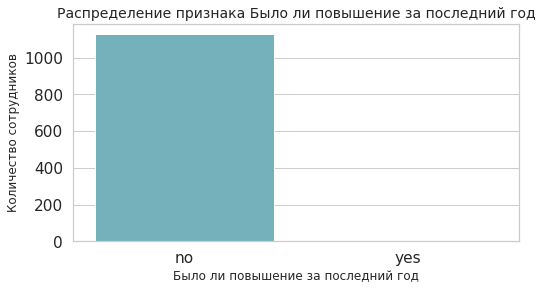

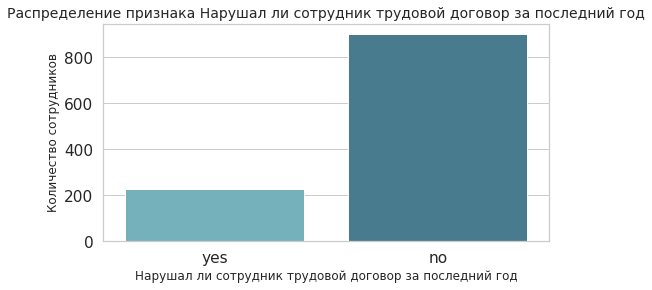

In [67]:
for i in range(len(cat_col)):
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=cat[i], palette='GnBu_d')
    plt.title(f"Распределение признака {titles_cat[i]}", size=14)
    plt.ylabel('Количество сотрудников', size=12)
    plt.xlabel(titles_cat[i], size=12)
    plt.show()

> Анализ категориальных признаков во вспомогательной таблице ушедших сотрудников показал, что наибольшее количество ушедших сотрудников работает в отделе продаж на позиции `junior` с низкой загруженностью и без повышения за последний год.
Кроме того, средняя зарплата уволившихся сотрудников на 10 000 рублей ниже, а оценка качества работы составляет 3 балла. Длительность работы в большинстве случаев составляет один год.

,dept,quit,proportion
0,hr,no,0.750000
1,hr,yes,0.250000
2,marketing,no,0.719931
3,marketing,yes,0.280069
4,purchasing,no,0.717687
5,purchasing,yes,0.282313
6,sales,no,0.716968
7,sales,yes,0.283032
8,technology,no,0.702586
9,technology,yes,0.297414


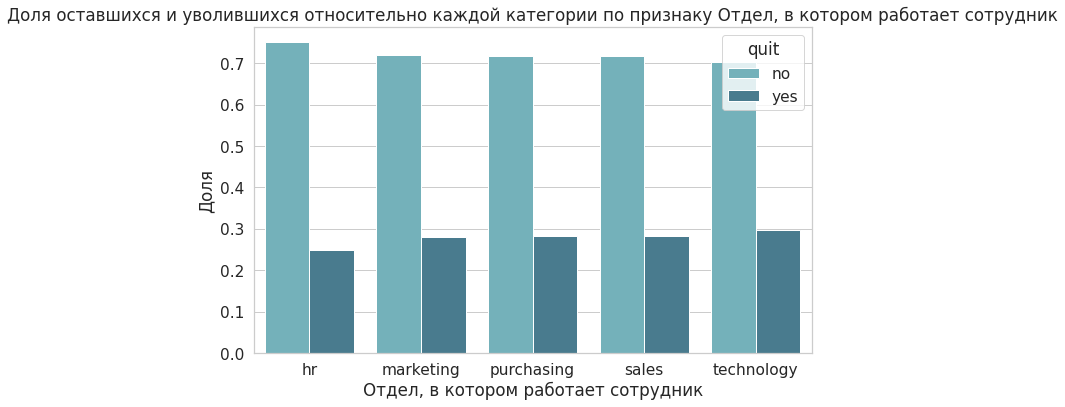

,level,quit,proportion
0,junior,yes,0.514623
1,junior,no,0.485377
2,middle,no,0.936246
3,middle,yes,0.063754
4,sinior,no,0.952381
5,sinior,yes,0.047619


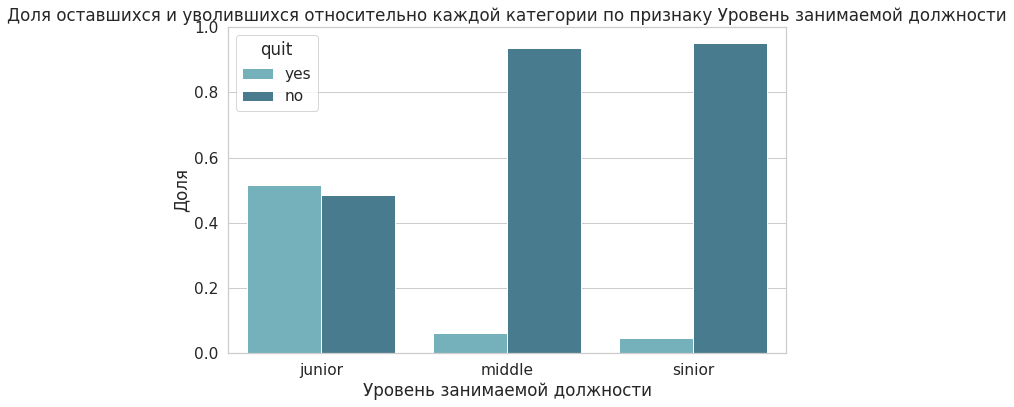

,workload,quit,proportion
0,high,no,0.820475
1,high,yes,0.179525
2,low,no,0.570364
3,low,yes,0.429636
4,medium,no,0.769594
5,medium,yes,0.230406


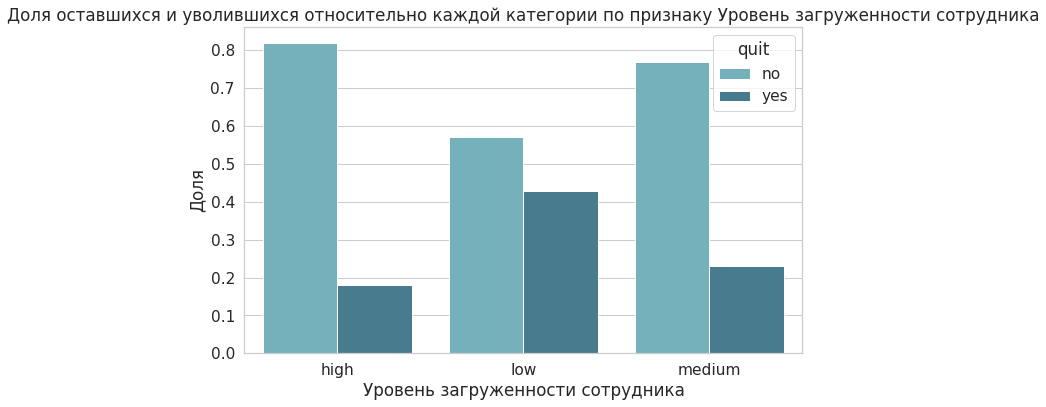

,last_year_promo,quit,proportion
0,no,no,0.710059
1,no,yes,0.289941
2,yes,no,0.991150
3,yes,yes,0.008850


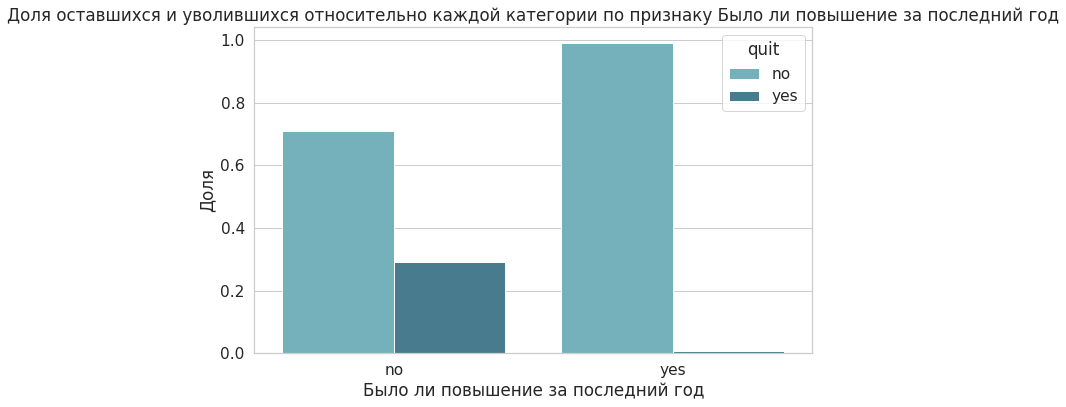

,last_year_violations,quit,proportion
0,no,no,0.739508
1,no,yes,0.260492
2,yes,no,0.581651
3,yes,yes,0.418349


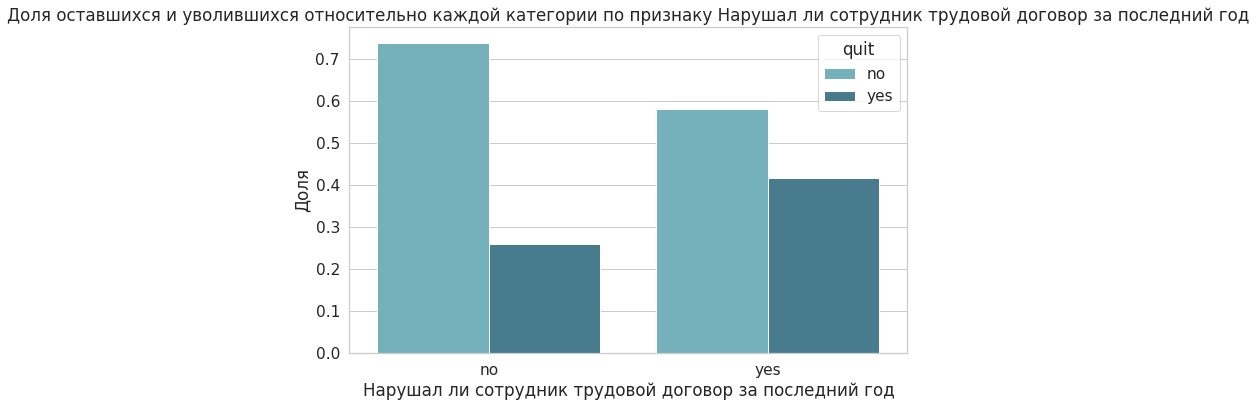

In [68]:
cat_cols = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
titles_cat = ['Отдел, в котором работает сотрудник', 'Уровень занимаемой должности', 'Уровень загруженности сотрудника',
             'Было ли повышение за последний год', 'Нарушал ли сотрудник трудовой договор за последний год']

for col in cat_cols:
    grouped = train_quit.groupby([col])['quit'].value_counts(normalize=True).reset_index(name='proportion')
    
    display(grouped)

    plt.figure(figsize=(10, 6))  
    sns.barplot(data=grouped, x=col, y='proportion', hue='quit', palette='GnBu_d')  
    plt.title(f'Доля оставшихся и уволившихся относительно каждой категории по признаку {titles_cat[cat_cols.index(col)]}')
    plt.xlabel(f'{titles_cat[cat_cols.index(col)]}')
    plt.ylabel('Доля')
    plt.show()

,dept,quit,proportion
0,hr,no,0.308511
1,hr,yes,0.102837
2,marketing,no,0.371454
3,marketing,yes,0.144504
4,purchasing,no,0.374113
5,purchasing,yes,0.147163
6,sales,no,0.914007
7,sales,yes,0.360816
8,technology,no,0.578014
9,technology,yes,0.244681


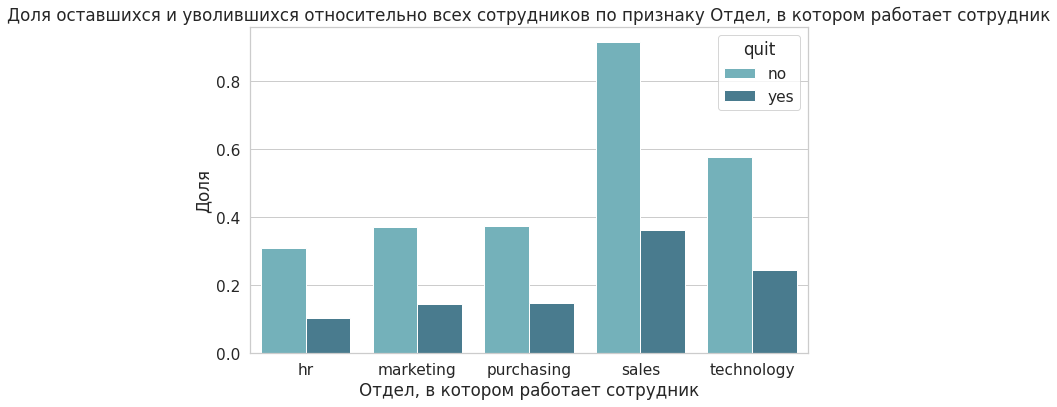

,level,quit,proportion
0,junior,no,0.838652
1,junior,yes,0.889184
2,middle,no,1.406028
3,middle,yes,0.095745
4,sinior,no,0.301418
5,sinior,yes,0.015071


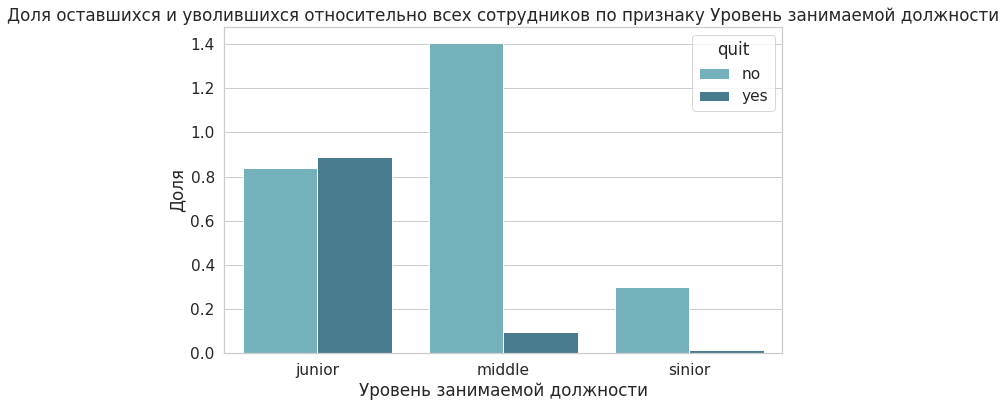

,workload,quit,proportion
0,high,no,0.490248
1,high,yes,0.107270
2,low,no,0.610816
3,low,yes,0.460106
4,medium,no,1.445035
5,medium,yes,0.432624


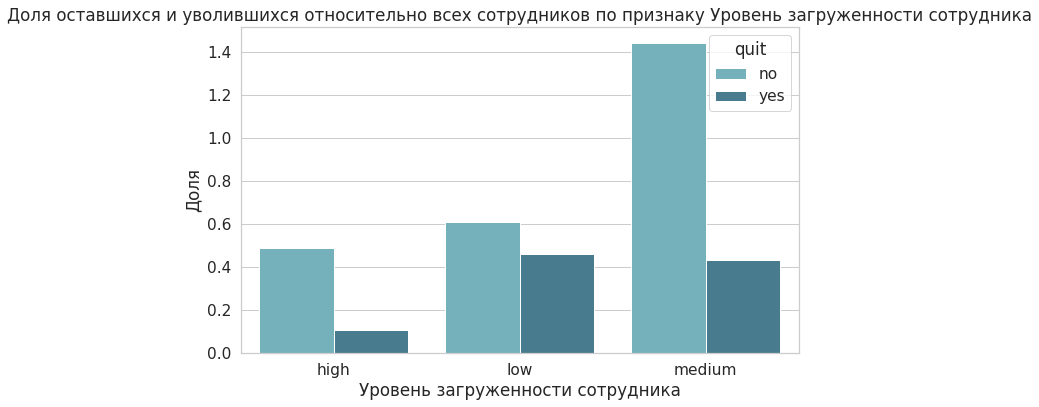

,last_year_promo,quit,proportion
0,no,no,2.446809
1,no,yes,0.999113
2,yes,no,0.099291
3,yes,yes,0.000887


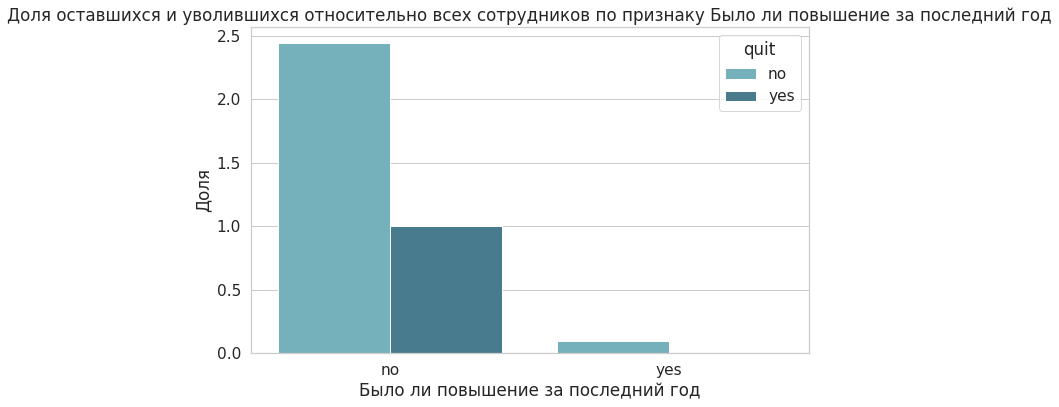

,last_year_violations,quit,proportion
0,no,no,2.265071
1,no,yes,0.797872
2,yes,no,0.281028
3,yes,yes,0.202128


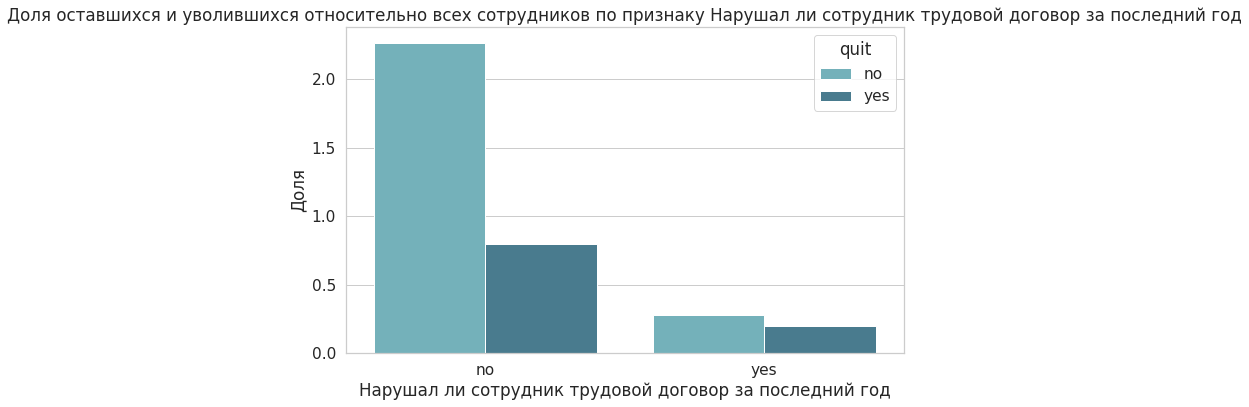

In [69]:
cat_cols = ['dept', 'level', 'workload', 'last_year_promo', 'last_year_violations']
titles_cat = ['Отдел, в котором работает сотрудник', 'Уровень занимаемой должности', 'Уровень загруженности сотрудника',
             'Было ли повышение за последний год', 'Нарушал ли сотрудник трудовой договор за последний год']

for col in cat_cols:
    grouped = train_quit.groupby([col, 'quit']).agg(proportion=('dept', lambda x: len(x) / len(df))).reset_index()
    
    display(grouped)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=grouped, x=col, y='proportion', hue='quit', palette='GnBu_d')
    plt.title(f'Доля оставшихся и уволившихся относительно всех сотрудников по признаку {titles_cat[cat_cols.index(col)]}')
    plt.xlabel(f'{titles_cat[cat_cols.index(col)]}')
    plt.ylabel('Доля')
    plt.show()

> Мы можем посмотреть долю оставшихся и уволившихся сотрудников в разрезе различных категорий, двумя способами. Например, в признаке с подразделениями `dept` всего 5 категорий (5 подразделений): HR, маркетинг, отдел закупки, продажи и технологический отдел. Первый способ предполагает, что мы будем смотреть на долю оставшихся/уволившихся относительно каждой категории отдельно. Т.е. каждая категория (каждое подразделение будет восприниматься как 100% и каждое подразделение разделено на уволившихся/оставшихся (первый скрин). По данному графику будет видно, что доля уволившихся в hr меньше всего, а в технологическом отделе уволившихся больше всего.  
Полученный график уже дает нам необходимую информацию по долям, но на данном графике не видно сколько всего работает людей и ошибочно можно предположить, что HR и технологические отделы различаются только тем, что в технологическом отделе больше увольняется сотрудников, чем в HR отделе. Поэтому можно посчитать доли по другому и построить второй вариант графика, на котором доля уволившихся/оставшихся будет относительно всех сотрудников (второй скрин). Тогда на графике будет сложнее понять, что доля уволившихся в технологическом отделе больше всего, но будет видно, что количество сотрудников между отделами значительно различается, в HR отделе меньше всего сотрудников, а в продажах больше всего.  

In [70]:
df_1 = test_target.merge(test_target_quit, on='id')
df_yes=df_1[df_1['quit'] == 'yes']
df_no=df_1[df_1['quit'] == 'no']

In [71]:
df_yes.head()

,id,job_satisfaction_rate,quit
2,418490,0.60,yes
4,826430,0.08,yes
20,508688,0.58,yes
29,343440,0.35,yes
30,622918,0.77,yes


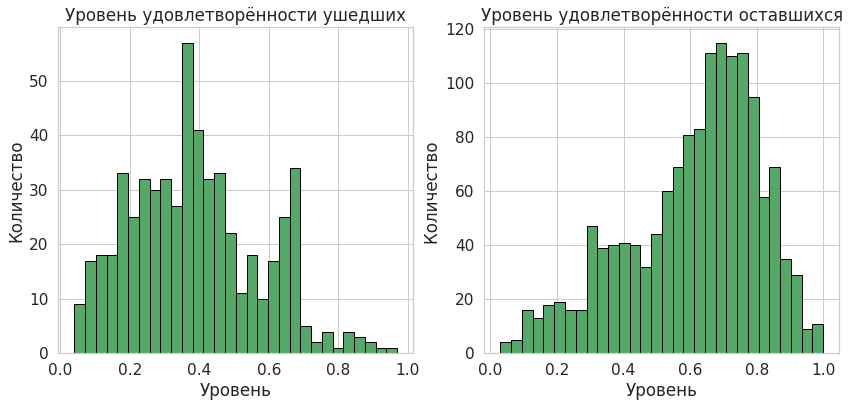

count    564.000000
mean       0.387713
std        0.185784
min        0.040000
25%        0.240000
50%        0.370000
75%        0.492500
max        0.970000
Name: job_satisfaction_rate, dtype: float64


count    1436.000000
mean        0.612040
std         0.199367
min         0.030000
25%         0.500000
50%         0.660000
75%         0.760000
max         1.000000
Name: job_satisfaction_rate, dtype: float64

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.hist(df_yes['job_satisfaction_rate'], bins = 30, color = 'g', ec='black')
ax1.set_title('Уровень удовлетворённости ушедших')
ax1.grid(True)
ax1.set_xlabel('Уровень')
ax1.set_ylabel('Количество')

ax2.hist(df_no['job_satisfaction_rate'], bins = 30, color = 'g',  ec='black')
ax2.set_title('Уровень удовлетворённости оставшихся')
ax2.grid(True)
ax2.set_xlabel('Уровень')
ax2.set_ylabel('Количество ')

plt.show()
print(df_yes['job_satisfaction_rate'].describe())
df_no['job_satisfaction_rate'].describe()

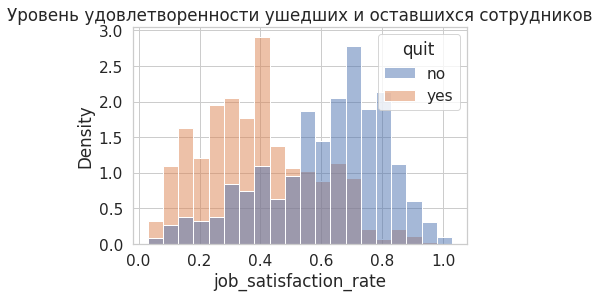

In [73]:
sns.histplot(data=df_1, x="job_satisfaction_rate", binwidth=0.05, hue="quit", stat='density', 
             common_norm=False).set (title='Уровень удовлетворенности ушедших и оставшихся сотрудников')
plt.show()

>Анализ данных о категориях ушедших сотрудников показал, что большинство уволившихся работали в отделе продаж на позициях `junior` с низким уровнем загруженности и без повышения за последний год.

>Также было выявлено, что средняя зарплата уволившихся сотрудников была на 10 000 рублей меньше, а оценка качества работы составляла 3 балла. Большинство сотрудников проработали в компании около года.

>Важно отметить, что предположение аналитиков оказалось верным: уровень удовлетворённости работой в компании влияет на решение сотрудника уйти, что подтверждается распределением показателя. Средняя оценка для ушедших сотрудников составила 0.387713, а для оставшихся — 0.612040.

## Шаг 4. Добавление нового входного признака

In [74]:
train_quit['job_satisfaction_rate'] = best_model.predict(train_quit)
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.640000
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.840769
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.340000
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.340000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


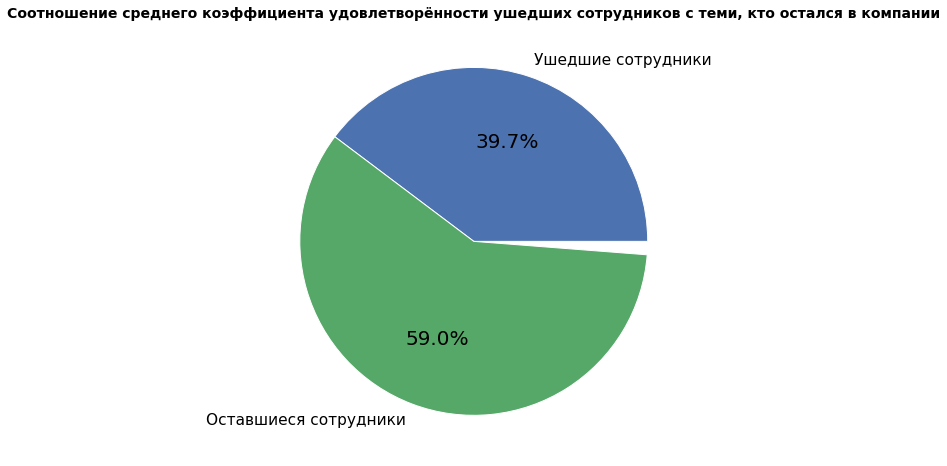

In [75]:
gone = train_quit['job_satisfaction_rate'][train_quit['quit'] == 'yes'].mean()
remained = train_quit['job_satisfaction_rate'][train_quit['quit'] == 'no'].mean()
data = [gone, remained]
labels = ['Ушедшие сотрудники', 'Оставшиеся сотрудники']
plt.figure(figsize=(8,8))
plt.rc('font', size= 20 ) 

fbcolor = ["b", "g"]

plt.pie(data, labels = labels, colors = fbcolor, autopct='%.1f%%', textprops={'color':'black'}, normalize=False)
plt.title('Соотношение среднего коэффициента удовлетворённости ушедших сотрудников с теми, кто остался в компании', fontsize=14, fontweight="bold", color='black')

plt.show() 

> Мы проанализировали дополнительные данные и сравнили средние показатели удовлетворённости между теми, кто ушёл, и теми, кто остался. Оказалось, что средний уровень удовлетворённости среди ушедших составил лишь 39,7 %.

## Шаг 5. Подготовка данных

In [76]:
test_features['job_satisfaction_rate'] = best_model.predict(test_features)
test_features[test_features.columns[test_features.columns != 'id']].describe()
test_features.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,485046,marketing,junior,medium,2,no,no,5,28800,0.859091
1,686555,hr,junior,medium,1,no,no,4,30000,0.682222
2,467458,sales,middle,low,5,no,no,4,19200,0.652000
3,418655,sales,middle,low,6,no,no,4,19200,0.666000
4,789145,hr,middle,medium,5,no,no,5,40800,0.825556


>Результаты модели DecisionTreeClassifier превзошли результаты Dummy Model, что указывает на её  эффективность.

## Шаг 6. Обучение модели

In [77]:
all_features = test_target_quit.merge(test_features, on='id')
descr(all_features)
all_features 

,id,quit,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,999029,yes,technology,junior,medium,1,no,no,3,31200,0.307143
1,372846,no,sales,middle,medium,10,no,yes,2,32400,0.206000
2,726767,no,marketing,middle,low,7,no,no,4,20400,0.600000
3,490105,no,purchasing,middle,low,7,no,no,4,19200,0.684000
4,416898,yes,purchasing,junior,low,1,no,no,4,12000,0.495000


<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   quit                   2000 non-null   object 
 2   dept                   1997 non-null   object 
 3   level                  1999 non-null   object 
 4   workload               1999 non-null   object 
 5   employment_years       2000 non-null   int64  
 6   last_year_promo        2000 non-null   object 
 7   last_year_violations   2000 non-null   object 
 8   supervisor_evaluation  2000 non-null   int64  
 9   salary                 2000 non-null   int64  
 10  job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 187.5+ KB


None

Количество дубликатов: 0
Количество пропусков: id                       0
quit                     0
dept                     3
level                    1
workload                 1
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64


,id,quit,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,999029,yes,technology,junior,medium,1,no,no,3,31200,0.307143
1,372846,no,sales,middle,medium,10,no,yes,2,32400,0.206000
2,726767,no,marketing,middle,low,7,no,no,4,20400,0.600000
3,490105,no,purchasing,middle,low,7,no,no,4,19200,0.684000
4,416898,yes,purchasing,junior,low,1,no,no,4,12000,0.495000
...,...,...,...,...,...,...,...,...,...,...,...
1995,836109,yes,sales,junior,high,1,no,no,3,33600,0.608182
1996,180999,yes,purchasing,junior,low,2,no,no,4,12000,0.666000
1997,746018,no,hr,middle,medium,2,no,no,4,46800,0.690000
1998,247658,no,sales,middle,medium,1,no,no,5,38400,0.625000


In [78]:
train_2 = train_quit.drop(['id'], axis=1)
train_2.drop_duplicates(inplace=True)
test_2 = all_features.drop(['quit','id'], axis=1)
target_2 = all_features['quit'] 

In [79]:
RANDOM_STATE = 100
TEST_SIZE = 0.25

X_train = train_2.drop('quit', axis=1)
y_train = train_2['quit'] 
X_test = test_2
y_test = target_2

ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']
ord_columns = ['level','workload',]
num_columns = ['employment_years', 'supervisor_evaluation', 'salary', 'job_satisfaction_rate']
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test= label_encoder.transform(y_test)  
   
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium', 'high'] 
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])
 
param_grid = [
     {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2,5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2,10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
    
]
# выберем лучшую модель и параметры с помощью RandomizedSearchCV()
r_search = RandomizedSearchCV(
    pipe_final, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# обучаем лучшую модель на тренировочных данных
r_search.fit(X_train, y_train)

# выводим на экран лучшую модель, её параметры и метрику ROC-AUC на тренировочной выборке
print('Лучшая модель и её параметры:\n\n', r_search.best_estimator_)
print(f'Параметры лучшей модели:\n{r_search.best_params_}')
print ('Метрика лучшей модели на тренировочной выборке:', round(r_search.best_score_, 4))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                            

In [80]:
best_model = r_search.best_estimator_

print(f'Метрика ROC-AUC лучшей модели по кросс-валидации на обучающих данных: {round(r_search.best_score_,4)}')
print(f'Метрика ROC-AUC лучшей модели на тестовой выборке: {round(roc_auc_score(y_test, r_search.predict_proba(X_test)[:, 1]),4)}')

Метрика ROC-AUC лучшей модели по кросс-валидации на обучающих данных: 0.9017
Метрика ROC-AUC лучшей модели на тестовой выборке: 0.9115


In [81]:
print(f'Метрика ROC-AUC лучшей модели на тестовой выборке: {round(roc_auc_score(y_test, r_search.predict_proba(X_test)[:, 1]),4)}')

Метрика ROC-AUC лучшей модели на тестовой выборке: 0.9115


In [82]:
# преобразовываем результаты в датафрейм и выводим результаты на экран
pd.DataFrame(r_search.cv_results_)[
    ['std_test_score', 'rank_test_score', 'param_models', 'mean_test_score','params']
].sort_values('rank_test_score')

,std_test_score,rank_test_score,param_models,mean_test_score,params
0,0.005905,1,DecisionTreeClassifier(random_state=100),0.901731,"{'preprocessor__num': 'passthrough', 'models__..."
9,0.008644,2,DecisionTreeClassifier(random_state=100),0.886371,"{'preprocessor__num': MinMaxScaler(), 'models_..."
5,0.005562,3,DecisionTreeClassifier(random_state=100),0.886233,"{'preprocessor__num': MinMaxScaler(), 'models_..."
3,0.027066,4,DecisionTreeClassifier(random_state=100),0.878488,"{'preprocessor__num': MinMaxScaler(), 'models_..."
4,0.007049,5,DecisionTreeClassifier(random_state=100),0.865922,"{'preprocessor__num': MinMaxScaler(), 'models_..."
8,0.007213,6,DecisionTreeClassifier(random_state=100),0.865752,"{'preprocessor__num': StandardScaler(), 'model..."
7,0.010942,7,DecisionTreeClassifier(random_state=100),0.857468,"{'preprocessor__num': MinMaxScaler(), 'models_..."
1,0.018899,8,DecisionTreeClassifier(random_state=100),0.848199,"{'preprocessor__num': MinMaxScaler(), 'models_..."
6,0.018871,9,DecisionTreeClassifier(random_state=100),0.848090,"{'preprocessor__num': StandardScaler(), 'model..."
2,0.018138,10,DecisionTreeClassifier(random_state=100),0.843876,"{'preprocessor__num': 'passthrough', 'models__..."


In [83]:
# создание и обучение модели DummyClassifier 
dummy_model = DummyClassifier(random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)

# предсказание на тестовых данных
dummy_model_preds = dummy_model.predict(X_test)

# считаем метрику ROC-AUC для тренировочных и тестовых данных
print('Метрики Dummy Model:')
d_roc_auc_cv = cross_val_score(dummy_model, X_train, y_train, scoring='roc_auc').mean()
print(f'ROC-AUC на тренировочной выборке: {round(d_roc_auc_cv, 3)}')

# оценка качества модели по метрике ROC-AUC
dummy_roc = roc_auc_score(y_test, dummy_model_preds)
print('ROC-AUC на тестовой выборке:', round(dummy_roc,2))

Метрики Dummy Model:
ROC-AUC на тренировочной выборке: 0.5
ROC-AUC на тестовой выборке: 0.5


Мы провели обучение модели, используя методы DecisionTreeClassifier(), KNeighborsClassifier() и RandomForestClassifier.

Обучение проводилось на исходных данных, а также на объединённых данных с выделением одного признака.

Лучшая модель имеет следующие параметры:

- preprocessor__num: passthrough;
    models__max_features: 4;
    models__max_depth: 5;
    models: DecisionTreeClassifier(random_state=100).
    Метрика модели на обучающей выборке составляет 0.901

- Mетрика ROC-AUC на тестовой выборке — 0.9115

## Шаг 7. Выводы

# Общий вывод

**Задача 1: предсказание уровня удовлетворённости сотрудника**

После обработки данных, мы привели их в порядок: стандартизировали названия признаков, скорректировали типы данных и обработали пропущенные значения. Анализ данных показал, что большинство сотрудников работают в компании от 2 до 6 лет, средний стаж составляет 3 года. Оценки качества сотрудников в основном на уровне 3 и 4 баллов, однако есть и те, у кого оценка равна 1, что может указывать на возможное увольнение. Средняя зарплата составляет около 33 926.70 тысяч рублей, причем уровень удовлетворенности работой соответствует оценкам качества. Большинство должностей занимают продавцы, а уровень занятости находится на среднем уровне. Повышения за последний год практически не было, что может быть стимулом к улучшению производительности. Корреляционный анализ показал взаимосвязь между удовлетворенностью работой и отделом, должностью и оценкой качества сотрудника. Обучение модели показало лучшие результаты с помощью DecisionTreeClassifier() и LinearRegression(), с параметрами, которые обеспечили метрику на кросс-валидации на уровне 15.1814.

**Задача 2: предсказание увольнения сотрудника из компании**

После загрузки данных мы провели предобработку, включая стандартизацию имен признаков, приведение типов данных к нужному формату, и проверку категориальных данных на наличие дубликатов и ошибок. Мы заменили пустые значения на nan в двух колонках и провели анализ на пропуски и дубликаты. Изучив категориальные признаки ушедших сотрудников, мы выявили, что больше всего уволившихся работников было в отделе продаж, с низким уровнем загруженности и без повышения за последний год. Средняя зарплата у уволенных была ниже на 10000 рублей, оценка их работоспособности составляла 3 бала, их средний стаж работы был около 1 года. Также мы обнаружили, что уровень удовлетворенности работой сотрудника влияет на вероятность его увольнения, что подтверждается статистикой. Мы добавили новый признак и посчитали средний коэффициент удовлетворенности среди уволенных, который составил 39.7%. После этого мы обучили несколько моделей, таких как DecisionTreeClassifier(), KNeighborsClassifier(), LinearRegression(). Лучшая модель, которая была выбрана, была DecisionTreeClassifier с метрикой 0.901 на тренировочной выборке и ROC-AUC метрикой 0.9115 на тестовой выборке.

**Дополнительные предложения для бизнеса**

Результаты анализа показали, что основная причина текучести кадров связана с сотрудниками, которые работают менее одного года. Это является нормальным явлением. Однако компании следует сосредоточиться на повышении удовлетворённости сотрудников, улучшая уровень заработной платы и загруженности, а также ввести промежуточные премии.